# Multiple Choice Question Evaluation for Zeolite Synthesis (GreenOnly Question Bank)

**Llama-3-8B-Instruct Evaluation**

This notebook evaluates LLM performance on multiple-choice questions about zeolite synthesis
using the **QuestionBank_GreenOnly.xlsx** dataset with 4 question categories.

**Question Categories (114 total):**
- Synthesis (30 questions)
- Chem Con & Catalysis (25 questions)
- Envir. Apps (DAC) (20 questions)
- Envir. Apps (General) (39 questions)

**Model:**
- Llama-3-8B-Instruct (GPU 3)

**Configuration:**
- k=10 and k=20
- 7 retrieval methods: Abstract baseline, No context, FAISS, MMR, BM25, Hybrid, LLM-Optimized
- Accuracy reported **per category** and **overall**

**Structure:**
- Phase 1: Abstract, No Context, FAISS (with intermediate results plot)
- Phase 2: MMR, BM25, Hybrid, LLM-Optimized (with full results plot)
- Phase 3: k=20 for all retrieval methods

Run with kernel v6 instead of v7

In [1]:
# Core imports
import os
import torch
import json
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import gc

# LangChain (for retrieval only) and Transformers
from langchain.prompts import ChatPromptTemplate
from langchain.llms import HuggingFacePipeline
from langchain.chains import LLMChain
from transformers import AutoTokenizer, AutoModelForCausalLM, GenerationConfig, pipeline

# Load HuggingFace token
!source /home/jupyter/Mrigi/env.sh
hf_token = os.environ.get("HF_TOKEN")

In [2]:
!nvidia-smi

Tue Feb 24 18:09:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.119.02             Driver Version: 580.119.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|


|   0  NVIDIA RTX A5000               Off |   00000000:31:00.0 Off |                  Off |
| 30%   41C    P0             67W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+------------------------+----------------------+
|   1  NVIDIA RTX A5000               Off |   00000000:4B:00.0 Off |                  Off |
| 30%   40C    P0             66W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+------------------------+----------------------+
|   2  NVIDIA RTX A5000               Off |   00000000:B1:00.0 Off |                  Off |
| 30%   40C    P0             62W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |            

In [3]:
!kill -9 107001

/bin/bash: line 0: kill: (107001) - No such process


In [4]:
# Model Configuration
MODELS = {
    'llama': {
        'name': 'meta-llama/Meta-Llama-3-8B-Instruct',
        'display_name': 'Llama-3-8B-Instruct',
        'gpu': 'cuda:3'
    }
}

K_VALUES = [10]
METHODS = ['abstract', 'no_context', 'faiss', 'mmr', 'bm25', 'hybrid', 'optimized']

def load_model(model_key):
    """
    Load a model on a specific GPU.
    
    Args:
        model_key: Key from MODELS dictionary
    
    Returns:
        tuple: (llm, model, tokenizer) - LangChain LLM and underlying components
    """
    config = MODELS[model_key]
    model_name = config['name']
    device = config['gpu']
    
    print(f"\n{'='*80}")
    print(f"Loading {config['display_name']} on {device}...")
    print(f"{'='*80}")
    
    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True,
        use_fast=True,
        token=hf_token
    )
    
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map=device,
        trust_remote_code=True,
        torch_dtype=torch.float16,
        token=hf_token
    )
    
    # Set up generation config
    generation_config = GenerationConfig.from_pretrained(model_name)
    generation_config.max_new_tokens = 100
    generation_config.temperature = 0.1
    
    # Set up pipeline
    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        generation_config=generation_config,
    )
    llm = HuggingFacePipeline(pipeline=pipe)
    
    print(f"✓ {config['display_name']} loaded successfully on {device}")
    print(f"  max_new_tokens=100, temperature=0.1, use_fast=True")
    
    return llm, model, tokenizer

def cleanup_model(model, tokenizer):
    """Clean up model from GPU memory."""
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    print("✓ GPU memory cleared")

print("✓ Model management functions defined")

✓ Model management functions defined


In [5]:
# Multiple choice prompt template
MC_PROMPT = """
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. You may use the provided context to inform your answer as well as your own knowledge. 

Provide your answer in the following format EXACTLY:
Answer: [LETTER] - [One sentence explanation]

For example:
Answer: B - The synthesis temperature was increased to improve crystallization.

Choose only from options A, B, C, D, or E.
Context:
{context}

Question: {question}
"""

In [6]:
def extract_completion(full_response, tokenizer):
    """
    Extract the assistant's completion from the full response using Llama special tokens.
    Splits on the assistant header tag to isolate just the model's output.
    """
    assistant_tag = "<|start_header_id|>assistant<|end_header_id|>"
    if assistant_tag in full_response:
        completion = full_response.split(assistant_tag)[-1].strip()
    else:
        completion = full_response.strip()
    
    # Remove any end-of-text tokens
    for token in ["<|eot_id|>", "<|end_of_text|>"]:
        completion = completion.replace(token, "").strip()
    
    return completion

def parse_mc_answer(completion):
    """
    Parse a multiple choice answer from the model's completion.
    Uses rfind to get the last 'Answer: ' occurrence (avoids matching the example).
    """
    last_answer_pos = completion.rfind("Answer: ")
    
    if last_answer_pos != -1:
        model_answer = completion[last_answer_pos + 8].upper()
        
        if model_answer in ['A', 'B', 'C', 'D', 'E']:
            explanation = ""
            answer_end = completion[last_answer_pos:].split('\n')[0]
            if '-' in answer_end:
                explanation = answer_end.split('-', 1)[1].strip()
            return model_answer, explanation
    
    return None, None

def evaluate_mc_response(llm, query, correct_answer, context, tokenizer):
    """Evaluate a single multiple choice question with context."""
    prompt_text = MC_PROMPT.format(context=context, question=query)
    
    # Apply Llama chat template with user role
    messages = [{"role": "user", "content": prompt_text}]
    formatted_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    try:
        # Get model's answer using direct call
        full_response = llm(formatted_prompt)
        
        # Extract assistant completion using special tokens
        completion = extract_completion(full_response, tokenizer)
        
        # Parse the answer
        model_answer, explanation = parse_mc_answer(completion)
        
        if model_answer is not None:
            return {
                'query': query,
                'context': context,
                'model_answer': model_answer,
                'correct_answer': correct_answer,
                'is_correct': model_answer == correct_answer,
                'full_response': completion,
                'explanation': explanation or ""
            }
        
        # No valid answer found
        return {
            'query': query,
            'context': context,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'full_response': completion,
            'error': "No valid answer found in response"
        }
        
    except Exception as e:
        print(f"Processing error: {str(e)}")
        return {
            'query': query,
            'context': context,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"Error processing response: {str(e)}"
        }

def evaluate_mc_no_context(llm, query, correct_answer, tokenizer):
    """Evaluate a single multiple choice question WITHOUT context."""
    NO_CONTEXT_PROMPT = """You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer.

Provide your answer in the following format EXACTLY:
Answer: [LETTER] - [One sentence explanation]

For example:
Answer: B - The synthesis temperature was increased to improve crystallization.

Choose only from options A, B, C, D, or E.

Question: {question}"""
    
    prompt_text = NO_CONTEXT_PROMPT.format(question=query)
    
    # Apply Llama chat template with user role
    messages = [{"role": "user", "content": prompt_text}]
    formatted_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    try:
        # Get model's answer using direct call
        full_response = llm(formatted_prompt)
        
        # Extract assistant completion using special tokens
        completion = extract_completion(full_response, tokenizer)
        
        # Parse the answer
        model_answer, explanation = parse_mc_answer(completion)
        
        if model_answer is not None:
            return {
                'query': query,
                'model_answer': model_answer,
                'correct_answer': correct_answer,
                'is_correct': model_answer == correct_answer,
                'full_response': completion,
                'explanation': explanation or ""
            }
        
        return {
            'query': query,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'full_response': completion,
            'error': "No valid answer found in response"
        }
        
    except Exception as e:
        print(f"Processing error: {str(e)}")
        return {
            'query': query,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"Error processing response: {str(e)}"
        }

print("✓ Evaluation functions defined (with chat template + special token parsing)")

✓ Evaluation functions defined (with chat template + special token parsing)


In [7]:
def get_faiss_context(query, k=10):
    """Retrieve context using FAISS similarity search."""
    results = vector_db.similarity_search(query, k=k)
    return "\n\n".join([doc.page_content for doc in results])

def get_mmr_context(query, k=10):
    """Retrieve context using Maximum Marginal Relevance."""
    results = vector_db.max_marginal_relevance_search(query, k=k)
    return "\n\n".join([doc.page_content for doc in results])

def get_bm25_context(query, k=10):
    """Retrieve context using BM25 retriever."""
    results = bm25_retriever.get_relevant_documents(query)[:k]
    return "\n\n".join([doc.page_content for doc in results])

def get_hybrid_context(query, k=10):
    """Retrieve context using hybrid (ensemble) retriever."""
    results = ensemble_retriever.get_relevant_documents(query)[:k]
    return "\n\n".join([doc.page_content for doc in results])

def get_optimized_context(query, llm, tokenizer, k=10):
    """Retrieve context using LLM-optimized retrieval."""
    # Apply chat template for the optimization prompt
    prompt_text = OPTIMIZE_QUERY_PROMPT.format(question=query)
    messages = [{"role": "user", "content": prompt_text}]
    formatted_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    # Get optimized query
    full_response = llm(formatted_prompt)
    optimized_query = extract_completion(full_response, tokenizer)
    
    # Clean up - take only first line
    optimized_query = optimized_query.split('\n')[0].strip()
    
    # Use optimized query for retrieval
    results = vector_db.similarity_search(optimized_query, k=k)
    return "\n\n".join([doc.page_content for doc in results])

# Unified evaluation function for all methods
def evaluate_method(llm, method_name, questions_df, tokenizer, k=10):
    """
    Evaluate a specific retrieval method.
    
    Args:
        llm: LangChain LLM instance
        method_name: Name of the method ('abstract', 'no_context', 'faiss', etc.)
        questions_df: DataFrame with questions
        tokenizer: Tokenizer for applying chat template
        k: Number of documents to retrieve
    
    Returns:
        dict: Results with accuracy and detailed responses
    """
    results = []
    
    for _, row in tqdm(questions_df.iterrows(), total=len(questions_df), 
                       desc=f"Evaluating {method_name} (k={k})"):
        query = row['Question']
        correct_answer = row['Correct_Answer']
        
        if method_name == 'abstract':
            context = row['Context']
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'no_context':
            result = evaluate_mc_no_context(llm, query, correct_answer, tokenizer)
        elif method_name == 'faiss':
            context = get_faiss_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'mmr':
            context = get_mmr_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'bm25':
            context = get_bm25_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'hybrid':
            context = get_hybrid_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'optimized':
            context = get_optimized_context(query, llm, tokenizer, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        else:
            raise ValueError(f"Unknown method: {method_name}")
        
        results.append(result)
    
    # Calculate accuracy
    correct_count = sum(1 for r in results if r.get('is_correct', False))
    total = len(results)
    accuracy = (correct_count / total) * 100 if total > 0 else 0
    
    return {
        'method': method_name,
        'k': k,
        'accuracy': accuracy,
        'correct_count': correct_count,
        'total': total,
        'detailed_results': results
    }

print("✓ Retrieval and unified evaluation functions defined")

✓ Retrieval and unified evaluation functions defined


In [8]:
# Load the vector database and retrieval components
from langchain.embeddings import SentenceTransformerEmbeddings
from langchain.vectorstores import FAISS
from langchain.retrievers import BM25Retriever
from pathlib import Path

# Initialize embeddings
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

# Load FAISS index
INDEX_DIRECTORY = Path("faiss_index")
INDEX_NAME = "index"

if not INDEX_DIRECTORY.exists():
    raise FileNotFoundError(f"Vector index directory '{INDEX_DIRECTORY}' not found.")

vector_db = FAISS.load_local(
    INDEX_DIRECTORY,
    embeddings,
    index_name=INDEX_NAME,
    allow_dangerous_deserialization=True
)
faiss_retriever = vector_db.as_retriever(search_kwargs={"k": 10})
print(f"\u2713 Loaded vector database from {INDEX_DIRECTORY} with {vector_db.index.ntotal} vectors")

# Get all documents for BM25
all_docs = vector_db.similarity_search("", k=vector_db.index.ntotal)
bm25_retriever = BM25Retriever.from_documents(all_docs)
bm25_retriever.k = 10
print(f"\u2713 Initialized BM25 retriever with {len(all_docs)} documents")

/tmp/ipykernel_4141882/2821454396.py:8: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")


✓ Loaded vector database from faiss_index with 1474439 vectors
✓ Initialized BM25 retriever with 1474439 documents
✓ Initialized BM25 retriever with 1474439 documents


In [9]:
# Define hybrid search function
from langchain.retrievers import EnsembleRetriever

def hybrid_search(query, vector_db, bm25_retriever, k_total=10, k_bm25=10, k_mmr=10, 
                  mmr_fetch_k=40, mmr_lambda=0.6):
    """
    Hybrid retrieval combining BM25 and MMR results.
    """
    # Get BM25 results
    bm25_retriever.k = k_bm25
    bm25_docs = bm25_retriever.get_relevant_documents(query)
    
    # Get MMR results
    mmr_docs = vector_db.max_marginal_relevance_search(
        query,
        k=k_mmr,
        fetch_k=mmr_fetch_k,
        lambda_mult=mmr_lambda
    )
    
    # Combine and deduplicate
    seen_content = set()
    combined_docs = []
    
    for doc in bm25_docs + mmr_docs:
        content_hash = hash(doc.page_content)
        if content_hash not in seen_content:
            seen_content.add(content_hash)
            combined_docs.append(doc)
            if len(combined_docs) >= k_total:
                break
    
    return combined_docs

# Create ensemble retriever for hybrid method
ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, faiss_retriever],
    weights=[0.5, 0.5]
)

print("\u2713 Hybrid search function and ensemble retriever defined")

✓ Hybrid search function and ensemble retriever defined


In [10]:
# Query optimizer prompt and function for LLM-optimized retrieval
OPTIMIZE_QUERY_PROMPT = """You are helping optimize multiple choice questions for academic literature search.
Given a multiple choice question about zeolite synthesis, extract the core scientific concepts and convert it into a concise keyword-based search query.
Focus on the main topic: materials, synthesis methods, characterization techniques, properties, or conditions being asked about.
Remove question phrasing, multiple choice options (A-E), and filler words.
Preserve chemical formulas, abbreviations, and domain-specific terminology.
Output a single line of lowercase keywords in a natural but compact order.
Do not explain or summarize—only output the optimized search query.

Question: {question}

Optimized query:"""

def optimize_query_for_mcq(question: str, llm, tokenizer) -> str:
    """
    Use LLM to convert a multiple choice question into an optimized search query.
    Uses chat template with special tokens for proper Llama formatting.
    """
    try:
        prompt_text = OPTIMIZE_QUERY_PROMPT.format(question=question)
        messages = [{"role": "user", "content": prompt_text}]
        formatted_prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        
        response = llm(formatted_prompt)
        completion = extract_completion(response, tokenizer)
        
        # Clean up - take only first line
        optimized_query = completion.split('\n')[0].strip()
        
        return optimized_query if optimized_query else question
    except Exception as e:
        print(f"Error optimizing query: {e}")
        return question

print("✓ Query optimizer prompt and function defined")

✓ Query optimizer prompt and function defined


In [11]:
# Load the question dataset from QuestionBank_GreenOnly.xlsx (4 sheets)
QUESTION_FILE = 'QuestionBank_GreenOnly.xlsx'

SHEET_NAMES = [
    'Synthesis',
    'Chem Con & Catalysis',
    'Envir. Apps (DAC)',
    'Envir. Apps (General)'
]

# Short labels for plots and results keys
CATEGORY_LABELS = {
    'Synthesis': 'Synthesis',
    'Chem Con & Catalysis': 'ChemCon',
    'Envir. Apps (DAC)': 'DAC',
    'Envir. Apps (General)': 'EnvirGen'
}

# Load each sheet into a dict of DataFrames
category_dfs = {}
for sheet in SHEET_NAMES:
    df = pd.read_excel(QUESTION_FILE, sheet_name=sheet)
    df = df.dropna(subset=['gpt_generated_question'])
    df = df.rename(columns={
        'gpt_generated_question': 'Question',
        'gpt_generated_answer': 'Correct_Answer',
        'abstract': 'Context'
    })
    df['Correct_Answer'] = df['Correct_Answer'].str.strip().str.upper()
    label = CATEGORY_LABELS[sheet]
    category_dfs[label] = df
    print(f"✓ {label}: {len(df)} questions loaded")

# Also create a combined DataFrame for overall accuracy
mc_questions_all = pd.concat(category_dfs.values(), ignore_index=True)
print(f"\n✓ Total: {len(mc_questions_all)} questions across {len(SHEET_NAMES)} categories")
print(f"✓ Categories: {list(category_dfs.keys())}")

✓ Synthesis: 30 questions loaded
✓ ChemCon: 25 questions loaded
✓ DAC: 20 questions loaded
✓ EnvirGen: 39 questions loaded

✓ Total: 114 questions across 4 categories
✓ Categories: ['Synthesis', 'ChemCon', 'DAC', 'EnvirGen']


## Phase 1: Abstract, No Context, and FAISS

Run the first three methods and generate an intermediate results plot.

In [12]:
# Initialize results storage and load model
# Results structure: all_results[model][k_label][category][method] = {accuracy, correct_count, total, detailed_results}
all_results = {}
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Load Llama model
llm, model, tokenizer = load_model('llama')
model_display_name = MODELS['llama']['display_name']
all_results[model_display_name] = {}

# Phase 1 methods
phase1_methods = ['abstract', 'no_context', 'faiss']
ALL_CATEGORIES = list(category_dfs.keys())  # ['Synthesis', 'ChemCon', 'DAC', 'EnvirGen']

for k in K_VALUES:
    print(f"\n{'='*80}")
    print(f"Running Phase 1 experiments with k={k}")
    print(f"{'='*80}")
    
    if f"k={k}" not in all_results[model_display_name]:
        all_results[model_display_name][f"k={k}"] = {}
    
    for category in ALL_CATEGORIES:
        if category not in all_results[model_display_name][f"k={k}"]:
            all_results[model_display_name][f"k={k}"][category] = {}
        
        questions_df = category_dfs[category]
        
        for method in phase1_methods:
            print(f"\n--- {category} | {method.upper()} | k={k} ({len(questions_df)} questions) ---")
            
            try:
                result = evaluate_method(llm, method, questions_df, tokenizer, k=k)
                all_results[model_display_name][f"k={k}"][category][method] = result
                
                print(f"✓ {result['accuracy']:.2f}% ({result['correct_count']}/{result['total']})")
                
            except Exception as e:
                print(f"✗ Error: {str(e)}")
                all_results[model_display_name][f"k={k}"][category][method] = {
                    'error': str(e), 'accuracy': 0, 'correct_count': 0, 'total': 0
                }
    
    # Save intermediate results (without detailed_results for JSON)
    temp_save_path = f'results_greenonly_phase1_intermediate_{timestamp}.json'
    save_results = {}
    for mn in all_results:
        save_results[mn] = {}
        for kl in all_results[mn]:
            save_results[mn][kl] = {}
            for cat in all_results[mn][kl]:
                save_results[mn][kl][cat] = {}
                for meth in all_results[mn][kl][cat]:
                    r = all_results[mn][kl][cat][meth]
                    save_results[mn][kl][cat][meth] = {
                        k2: v for k2, v in r.items() if k2 != 'detailed_results'
                    }
    with open(temp_save_path, 'w') as f:
        json.dump(save_results, f, indent=2)

print(f"\n{'='*80}")
print(f"Phase 1 complete!")
print(f"{'='*80}")


Loading Llama-3-8B-Instruct on cuda:3...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/tmp/ipykernel_4141882/4282598661.py:59: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=pipe)


✓ Llama-3-8B-Instruct loaded successfully on cuda:3
  max_new_tokens=100, temperature=0.1, use_fast=True

Running Phase 1 experiments with k=10

--- Synthesis | ABSTRACT | k=10 (30 questions) ---


...

✓ 94.87% (37/39)

--- EnvirGen | NO_CONTEXT | k=10 (39 questions) ---


Evaluating no_context (k=10):   0%|          | 0/39 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order 

✓ 82.05% (32/39)

--- EnvirGen | FAISS | k=10 (39 questions) ---


Evaluating faiss (k=10):   0%|          | 0/39 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to ma

✓ 69.23% (27/39)

Phase 1 complete!



PHASE 1 RESULTS: Abstract, No Context, FAISS (per category)
Category        Method          Accuracy     Correct/Total  
------------------------------------------------------------------------------------------
Synthesis       abstract        100.00%      30/30
Synthesis       no_context       86.67%      26/30
Synthesis       faiss            90.00%      27/30
------------------------------------------------------------------------------------------
ChemCon         abstract        100.00%      25/25
ChemCon         no_context       96.00%      24/25
ChemCon         faiss            96.00%      24/25
------------------------------------------------------------------------------------------
DAC             abstract        100.00%      20/20
DAC             no_context      100.00%      20/20
DAC             faiss           100.00%      20/20
------------------------------------------------------------------------------------------
EnvirGen        abstract         94.87%      37/39
Envi

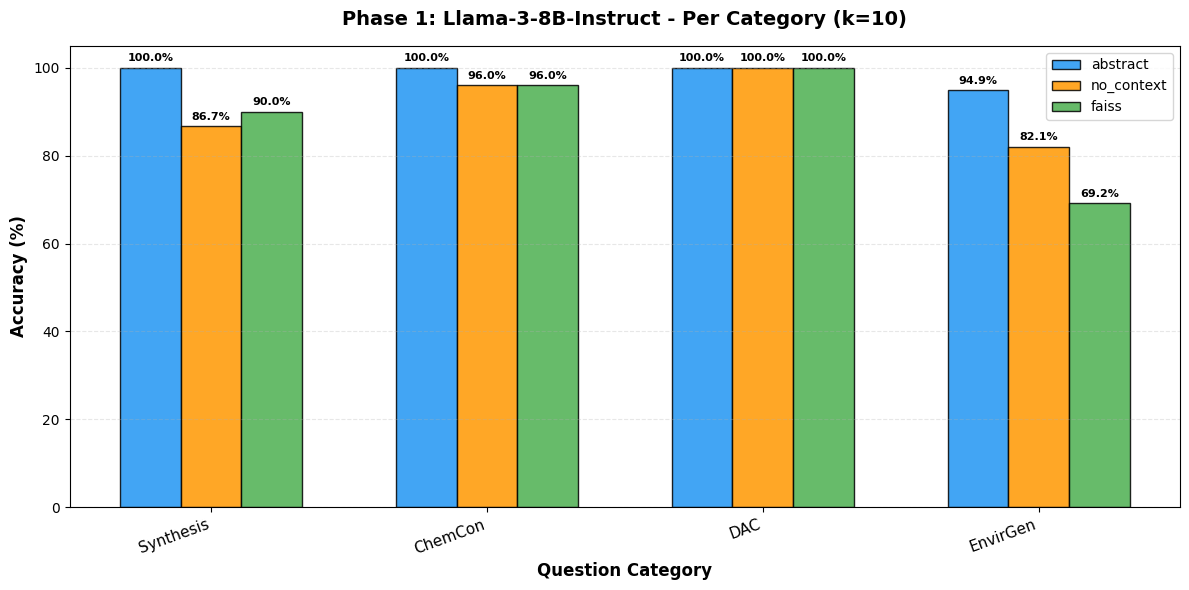

✓ Phase 1 per-category bar chart generated


In [13]:
# Phase 1 Results: Per-category + overall bar charts
import matplotlib.pyplot as plt
import numpy as np

phase1_methods = ['abstract', 'no_context', 'faiss']
method_colors = {'abstract': '#2196F3', 'no_context': '#FF9800', 'faiss': '#4CAF50'}

# --- Print summary table ---
print("\n" + "="*90)
print("PHASE 1 RESULTS: Abstract, No Context, FAISS (per category)")
print("="*90)
print(f"{'Category':<15} {'Method':<15} {'Accuracy':<12} {'Correct/Total':<15}")
print("-"*90)
for cat in ALL_CATEGORIES:
    for method in phase1_methods:
        r = all_results[model_display_name]['k=10'][cat][method]
        print(f"{cat:<15} {method:<15} {r['accuracy']:>6.2f}%      {r['correct_count']}/{r['total']}")
    print("-"*90)

# Overall accuracy (sum correct / sum total across categories)
print(f"\n{'OVERALL':<15}", end="")
for method in phase1_methods:
    total_correct = sum(all_results[model_display_name]['k=10'][cat][method]['correct_count'] for cat in ALL_CATEGORIES)
    total_n = sum(all_results[model_display_name]['k=10'][cat][method]['total'] for cat in ALL_CATEGORIES)
    overall_acc = (total_correct / total_n * 100) if total_n > 0 else 0
    print(f"  {method}: {overall_acc:.2f}% ({total_correct}/{total_n})", end="")
print()
print("="*90)

# --- Grouped bar chart: 4 categories, 3 methods each ---
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(ALL_CATEGORIES))
bar_width = 0.22

for i, method in enumerate(phase1_methods):
    accs = [all_results[model_display_name]['k=10'][cat][method]['accuracy'] for cat in ALL_CATEGORIES]
    bars = ax.bar(x + i * bar_width, accs, bar_width, label=method, 
                  color=method_colors[method], alpha=0.85, edgecolor='black')
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=8)

ax.set_xlabel('Question Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Phase 1: {model_display_name} - Per Category (k=10)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + bar_width)
ax.set_xticklabels(ALL_CATEGORIES, rotation=20, ha='right', fontsize=11)
ax.legend(loc='upper right', frameon=True, fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()
print("✓ Phase 1 per-category bar chart generated")

## Phase 2: MMR, BM25, Hybrid, LLM-Optimized

Run the remaining four retrieval methods.

In [14]:
# Phase 2 methods
phase2_methods = ['mmr', 'bm25', 'hybrid', 'optimized']

for k in K_VALUES:
    print(f"\n{'='*80}")
    print(f"Running Phase 2 experiments with k={k}")
    print(f"{'='*80}")
    
    for category in ALL_CATEGORIES:
        questions_df = category_dfs[category]
        
        for method in phase2_methods:
            print(f"\n--- {category} | {method.upper()} | k={k} ({len(questions_df)} questions) ---")
            
            try:
                result = evaluate_method(llm, method, questions_df, tokenizer, k=k)
                all_results[model_display_name][f"k={k}"][category][method] = result
                
                print(f"✓ {result['accuracy']:.2f}% ({result['correct_count']}/{result['total']})")
                
            except Exception as e:
                print(f"✗ Error: {str(e)}")
                all_results[model_display_name][f"k={k}"][category][method] = {
                    'error': str(e), 'accuracy': 0, 'correct_count': 0, 'total': 0
                }
    
    # Save intermediate results
    temp_save_path = f'results_greenonly_phase2_intermediate_{timestamp}.json'
    save_results = {}
    for mn in all_results:
        save_results[mn] = {}
        for kl in all_results[mn]:
            save_results[mn][kl] = {}
            for cat in all_results[mn][kl]:
                save_results[mn][kl][cat] = {}
                for meth in all_results[mn][kl][cat]:
                    r = all_results[mn][kl][cat][meth]
                    save_results[mn][kl][cat][meth] = {
                        k2: v for k2, v in r.items() if k2 != 'detailed_results'
                    }
    with open(temp_save_path, 'w') as f:
        json.dump(save_results, f, indent=2)

print(f"\n{'='*80}")
print(f"Phase 2 complete!")
print(f"{'='*80}")


Running Phase 2 experiments with k=10

--- Synthesis | MMR | k=10 (30 questions) ---


Evaluating mmr (k=10):   0%|          | 0/30 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maxi

✓ 96.67% (29/30)

--- Synthesis | BM25 | k=10 (30 questions) ---


Evaluating bm25 (k=10):   0%|          | 0/30 [00:00<?, ?it/s]/tmp/ipykernel_4141882/300316852.py:13: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  results = bm25_retriever.get_relevant_documents(query)[:k]
/tmp/ipykernel_4141882/300316852.py:13: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  results = bm25_retriever.get_relevant_documents(query)[:k]
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but i

✓ 86.67% (26/30)

--- Synthesis | HYBRID | k=10 (30 questions) ---


...

✓ 84.62% (33/39)

--- EnvirGen | HYBRID | k=10 (39 questions) ---


Evaluating hybrid (k=10):   0%|          | 0/39 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to m

✓ 89.74% (35/39)

--- EnvirGen | OPTIMIZED | k=10 (39 questions) ---


Evaluating optimized (k=10):   0%|          | 0/39 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order t

✓ 74.36% (29/39)

Phase 2 complete!


## Full Results: All Methods at k=10 (Per Category + Overall)


FULL RESULTS: All 7 Methods at k=10 (per category + overall)
Category        Method          Accuracy     Correct/Total  
----------------------------------------------------------------------------------------------------
Synthesis       abstract        100.00%      30/30
Synthesis       no_context       86.67%      26/30
Synthesis       faiss            90.00%      27/30
Synthesis       mmr              96.67%      29/30
Synthesis       bm25             86.67%      26/30
Synthesis       hybrid           93.33%      28/30
Synthesis       optimized        83.33%      25/30
----------------------------------------------------------------------------------------------------
ChemCon         abstract        100.00%      25/25
ChemCon         no_context       96.00%      24/25
ChemCon         faiss            96.00%      24/25
ChemCon         mmr              96.00%      24/25
ChemCon         bm25            100.00%      25/25
ChemCon         hybrid           96.00%      24/25
ChemCon     

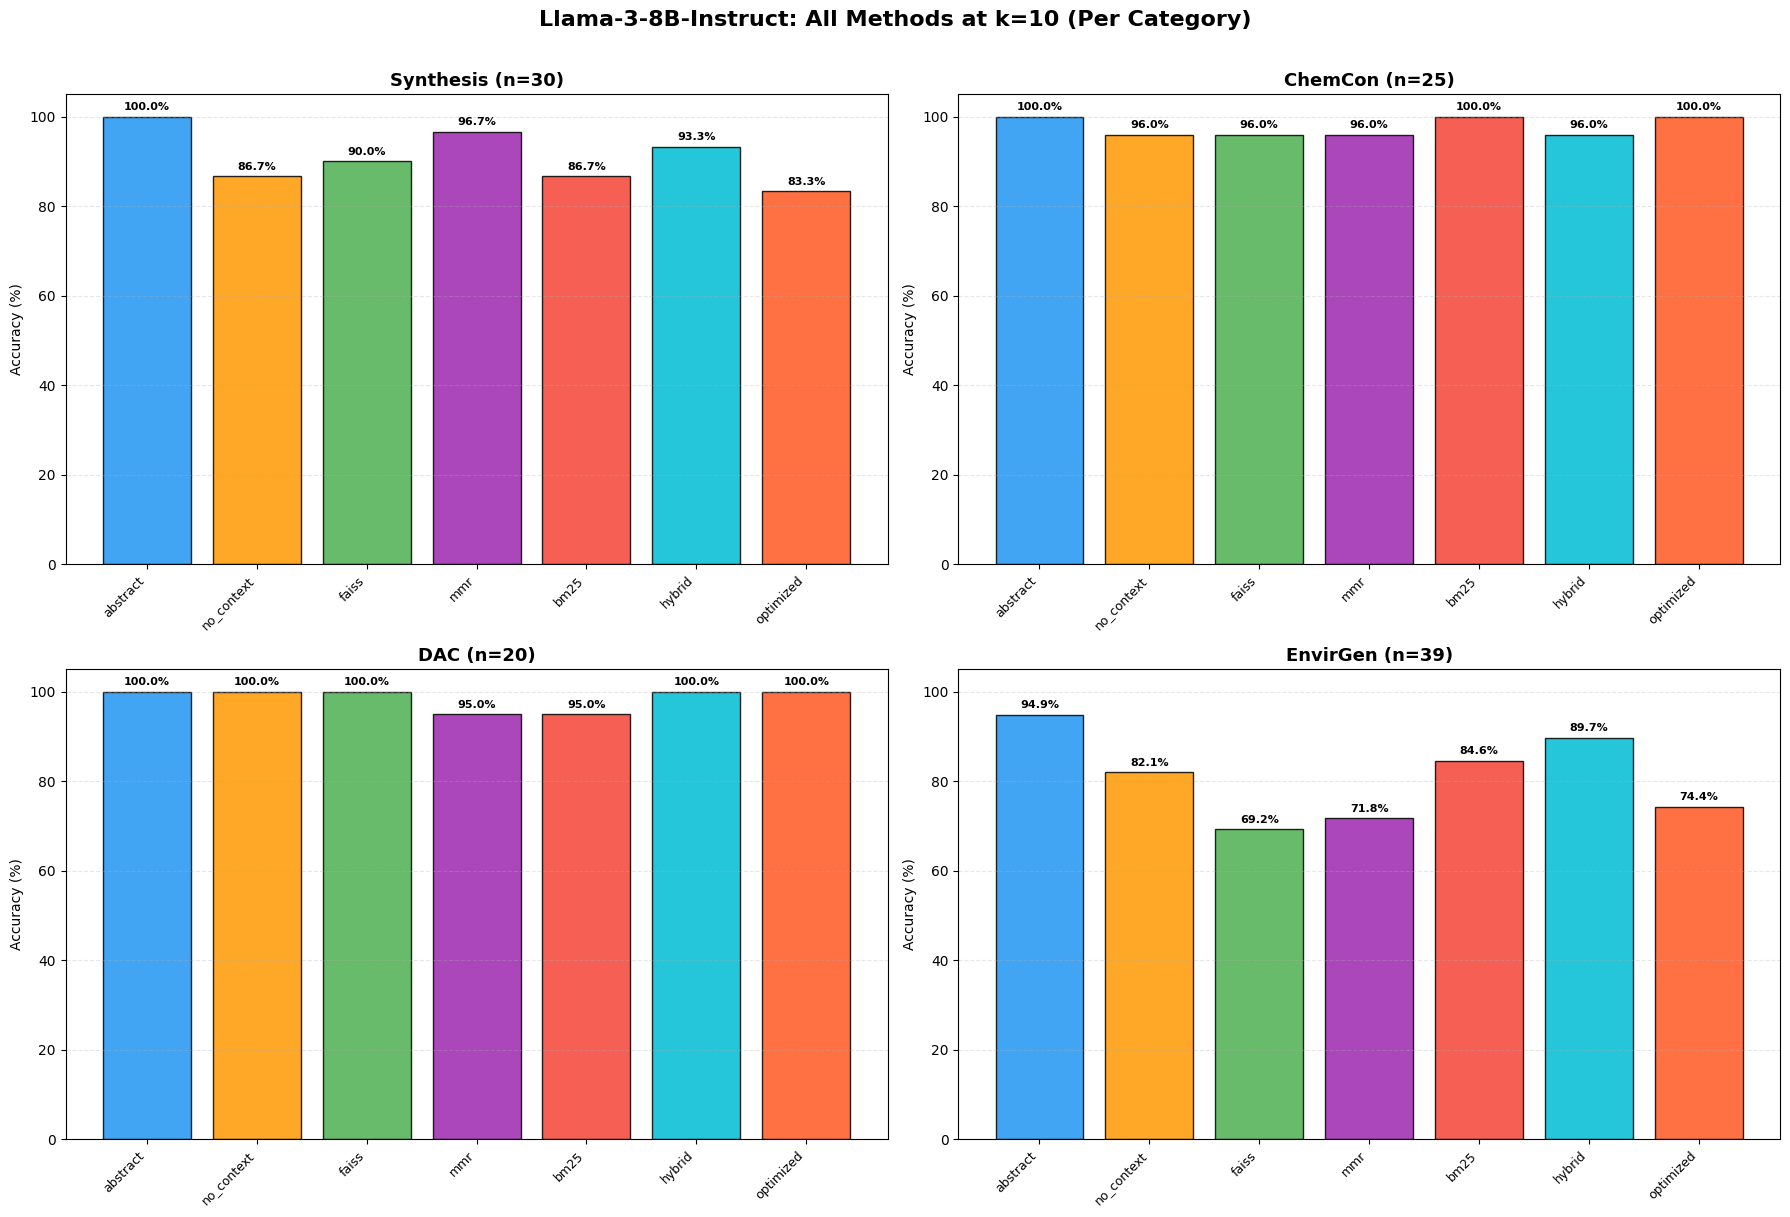

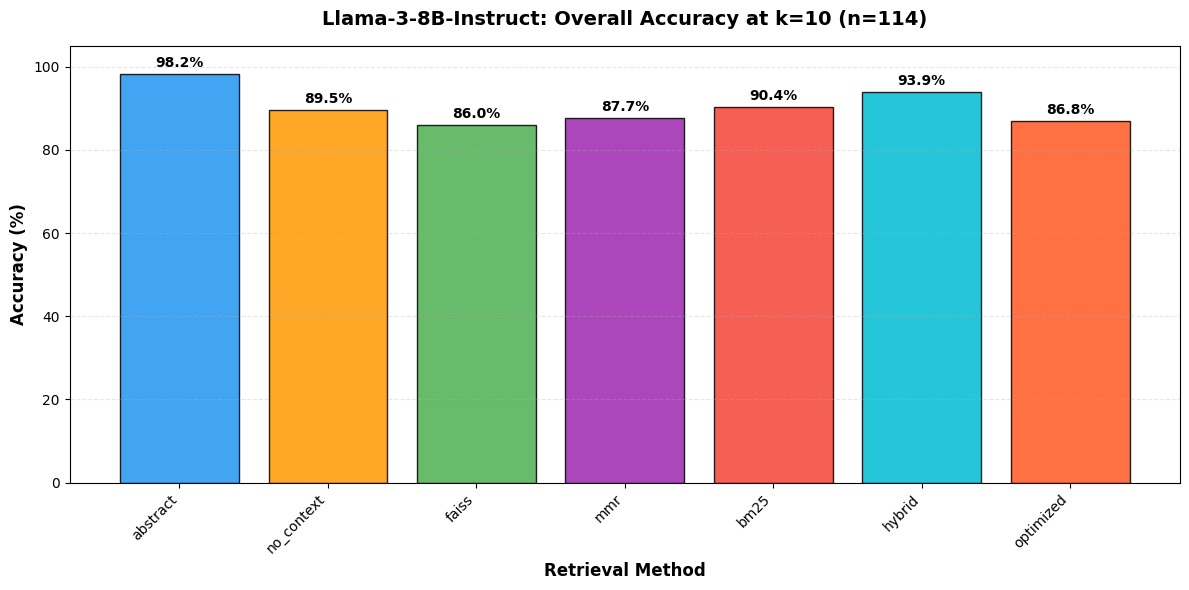

✓ Full results charts generated (per-category + overall)


In [15]:
# Full Results: Per-category + overall bar chart for all 7 methods at k=10
import matplotlib.pyplot as plt
import numpy as np

all_methods_list = ['abstract', 'no_context', 'faiss', 'mmr', 'bm25', 'hybrid', 'optimized']
method_colors_all = {
    'abstract': '#2196F3', 'no_context': '#FF9800', 'faiss': '#4CAF50',
    'mmr': '#9C27B0', 'bm25': '#F44336', 'hybrid': '#00BCD4', 'optimized': '#FF5722'
}

# --- Print full summary table ---
print("\n" + "="*100)
print("FULL RESULTS: All 7 Methods at k=10 (per category + overall)")
print("="*100)
print(f"{'Category':<15} {'Method':<15} {'Accuracy':<12} {'Correct/Total':<15}")
print("-"*100)

for cat in ALL_CATEGORIES:
    for method in all_methods_list:
        r = all_results[model_display_name]['k=10'][cat][method]
        print(f"{cat:<15} {method:<15} {r['accuracy']:>6.2f}%      {r['correct_count']}/{r['total']}")
    print("-"*100)

# Overall
print(f"\n{'OVERALL':}")
print(f"{'Method':<15} {'Accuracy':<12} {'Correct/Total':<15}")
print("-"*50)
for method in all_methods_list:
    total_correct = sum(all_results[model_display_name]['k=10'][cat][method]['correct_count'] for cat in ALL_CATEGORIES)
    total_n = sum(all_results[model_display_name]['k=10'][cat][method]['total'] for cat in ALL_CATEGORIES)
    overall_acc = (total_correct / total_n * 100) if total_n > 0 else 0
    print(f"{method:<15} {overall_acc:>6.2f}%      {total_correct}/{total_n}")
print("="*100)

# --- Per-category grouped bar chart: 4 panels ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, cat in enumerate(ALL_CATEGORIES):
    ax = axes[idx]
    accs = [all_results[model_display_name]['k=10'][cat][m]['accuracy'] for m in all_methods_list]
    colors = [method_colors_all[m] for m in all_methods_list]
    
    x = np.arange(len(all_methods_list))
    bars = ax.bar(x, accs, color=colors, alpha=0.85, edgecolor='black')
    
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=8)
    
    n_q = len(category_dfs[cat])
    ax.set_title(f'{cat} (n={n_q})', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(all_methods_list, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Accuracy (%)')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, 105)

fig.suptitle(f'{model_display_name}: All Methods at k=10 (Per Category)', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Overall bar chart ---
fig2, ax2 = plt.subplots(figsize=(12, 6))
overall_accs = []
for method in all_methods_list:
    tc = sum(all_results[model_display_name]['k=10'][cat][method]['correct_count'] for cat in ALL_CATEGORIES)
    tn = sum(all_results[model_display_name]['k=10'][cat][method]['total'] for cat in ALL_CATEGORIES)
    overall_accs.append((tc / tn * 100) if tn > 0 else 0)

x = np.arange(len(all_methods_list))
colors = [method_colors_all[m] for m in all_methods_list]
bars = ax2.bar(x, overall_accs, color=colors, alpha=0.85, edgecolor='black')

for bar, acc in zip(bars, overall_accs):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

ax2.set_xlabel('Retrieval Method', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title(f'{model_display_name}: Overall Accuracy at k=10 (n=114)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(all_methods_list, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

print("✓ Full results charts generated (per-category + overall)")

In [16]:
# Export k=10 results to CSV (per-category + overall)
export_data = []

for cat in ALL_CATEGORIES:
    for method in all_methods_list:
        r = all_results[model_display_name]['k=10'][cat][method]
        export_data.append({
            'model': model_display_name,
            'k': 10,
            'category': cat,
            'method': method,
            'accuracy': r.get('accuracy', 0),
            'correct': r.get('correct_count', 0),
            'total': r.get('total', 0)
        })

# Add overall rows
for method in all_methods_list:
    tc = sum(all_results[model_display_name]['k=10'][cat][method]['correct_count'] for cat in ALL_CATEGORIES)
    tn = sum(all_results[model_display_name]['k=10'][cat][method]['total'] for cat in ALL_CATEGORIES)
    export_data.append({
        'model': model_display_name,
        'k': 10,
        'category': 'Overall',
        'method': method,
        'accuracy': (tc / tn * 100) if tn > 0 else 0,
        'correct': tc,
        'total': tn
    })

export_df = pd.DataFrame(export_data)
csv_filename = f'results_greenonly_k10_{timestamp}.csv'
export_df.to_csv(csv_filename, index=False)
print(f"Results exported to CSV: {csv_filename}")
print(f"Total rows: {len(export_df)}")
print(export_df.to_string(index=False))

Results exported to CSV: results_greenonly_k10_20260224_181133.csv
Total rows: 35
              model  k  category     method   accuracy  correct  total
Llama-3-8B-Instruct 10 Synthesis   abstract 100.000000       30     30
Llama-3-8B-Instruct 10 Synthesis no_context  86.666667       26     30
Llama-3-8B-Instruct 10 Synthesis      faiss  90.000000       27     30
Llama-3-8B-Instruct 10 Synthesis        mmr  96.666667       29     30
Llama-3-8B-Instruct 10 Synthesis       bm25  86.666667       26     30
Llama-3-8B-Instruct 10 Synthesis     hybrid  93.333333       28     30
Llama-3-8B-Instruct 10 Synthesis  optimized  83.333333       25     30
Llama-3-8B-Instruct 10   ChemCon   abstract 100.000000       25     25
Llama-3-8B-Instruct 10   ChemCon no_context  96.000000       24     25
Llama-3-8B-Instruct 10   ChemCon      faiss  96.000000       24     25
Llama-3-8B-Instruct 10   ChemCon        mmr  96.000000       24     25
Llama-3-8B-Instruct 10   ChemCon       bm25 100.000000       25   

## Phase 3: k=20 Evaluation for All Retrieval Methods (Per Category)

Run all 5 retrieval methods (FAISS, MMR, BM25, Hybrid, LLM-Optimized) with k=20 across all 4 categories.
The baselines (abstract and no_context) are k-independent and already computed above.

In [17]:
# Phase 3: Run all retrieval methods with k=20 across all categories
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"
print("Set PYTORCH_CUDA_ALLOC_CONF=max_split_size_mb:128")

def evaluate_method_with_cache_clear(llm, method_name, questions_df, tokenizer, k=20):
    """
    Same as evaluate_method but clears GPU cache after each question
    to prevent OOM errors with large k values.
    """
    results = []
    
    for _, row in tqdm(questions_df.iterrows(), total=len(questions_df), 
                       desc=f"Evaluating {method_name} (k={k})"):
        query = row['Question']
        correct_answer = row['Correct_Answer']
        
        if method_name == 'faiss':
            context = get_faiss_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'mmr':
            context = get_mmr_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'bm25':
            context = get_bm25_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'hybrid':
            context = get_hybrid_context(query, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        elif method_name == 'optimized':
            context = get_optimized_context(query, llm, tokenizer, k=k)
            result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
        else:
            raise ValueError(f"Unknown method: {method_name}")
        
        results.append(result)
        torch.cuda.empty_cache()
    
    correct_count = sum(1 for r in results if r.get('is_correct', False))
    total = len(results)
    accuracy = (correct_count / total) * 100 if total > 0 else 0
    
    return {
        'method': method_name, 'k': k,
        'accuracy': accuracy, 'correct_count': correct_count,
        'total': total, 'detailed_results': results
    }

k20_methods = ['faiss', 'mmr', 'bm25', 'hybrid', 'optimized']
k20 = 20

torch.cuda.empty_cache()
gc.collect()
print("Cleared GPU cache before k=20 experiments")

# Initialize k=20 storage
if f"k={k20}" not in all_results[model_display_name]:
    all_results[model_display_name][f"k={k20}"] = {}

print(f"\n{'='*80}")
print(f"Running k=20 experiments across all categories")
print(f"{'='*80}")

for category in ALL_CATEGORIES:
    if category not in all_results[model_display_name][f"k={k20}"]:
        all_results[model_display_name][f"k={k20}"][category] = {}
    
    questions_df = category_dfs[category]
    
    for method in k20_methods:
        print(f"\n--- {category} | {method.upper()} | k={k20} ({len(questions_df)} questions) ---")
        
        torch.cuda.empty_cache()
        
        try:
            result = evaluate_method_with_cache_clear(llm, method, questions_df, tokenizer, k=k20)
            all_results[model_display_name][f"k={k20}"][category][method] = result
            
            print(f"✓ {result['accuracy']:.2f}% ({result['correct_count']}/{result['total']})")
            
        except Exception as e:
            print(f"✗ Error: {str(e)}")
            all_results[model_display_name][f"k={k20}"][category][method] = {
                'error': str(e), 'accuracy': 0, 'correct_count': 0, 'total': 0
            }
    
    # Save after each category
    temp_save_path = f'results_greenonly_k20_intermediate_{timestamp}.json'
    save_results = {}
    for mn in all_results:
        save_results[mn] = {}
        for kl in all_results[mn]:
            save_results[mn][kl] = {}
            for cat in all_results[mn][kl]:
                save_results[mn][kl][cat] = {}
                for meth in all_results[mn][kl][cat]:
                    r = all_results[mn][kl][cat][meth]
                    save_results[mn][kl][cat][meth] = {
                        k2: v for k2, v in r.items() if k2 != 'detailed_results'
                    }
    with open(temp_save_path, 'w') as f:
        json.dump(save_results, f, indent=2, ensure_ascii=True)

print(f"\n{'='*80}")
print(f"k=20 experiments complete!")
print(f"{'='*80}")

Set PYTORCH_CUDA_ALLOC_CONF=max_split_size_mb:128
Cleared GPU cache before k=20 experiments

Running k=20 experiments across all categories

--- Synthesis | FAISS | k=20 (30 questions) ---


Evaluating faiss (k=20):   0%|          | 0/30 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to ma

Processing error: CUDA out of memory. Tried to allocate 3.31 GiB (GPU 3; 23.55 GiB total capacity; 17.15 GiB already allocated; 2.19 GiB free; 20.50 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF


Evaluating faiss (k=20):  37%|███▋      | 11/30 [00:27<00:44,  2.33s/it]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In or

Processing error: CUDA out of memory. Tried to allocate 2.88 GiB (GPU 3; 23.55 GiB total capacity; 16.89 GiB already allocated; 2.88 GiB free; 19.81 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF


...

Processing error: CUDA out of memory. Tried to allocate 1.87 GiB (GPU 3; 23.55 GiB total capacity; 20.97 GiB already allocated; 1.62 GiB free; 21.07 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF


Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001

✓ 79.49% (31/39)

--- EnvirGen | OPTIMIZED | k=20 (39 questions) ---


Evaluating optimized (k=20):   0%|          | 0/39 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order t

✓ 71.79% (28/39)

k=20 experiments complete!


## Combined Results: k=10 vs k=20 with Baselines (Per Category + Overall)

Per-category grouped bar charts comparing all retrieval methods at k=10 and k=20, alongside the two k-independent baselines (Abstract and No Context).


COMBINED RESULTS: Baselines + k=10 vs k=20 (Per Category + Overall)

--- Synthesis ---
Method          Baseline     k=10         k=20         k10→k20     
------------------------------------------------------------
abstract        100.00%          --           --           --
no_context       86.67%          --           --           --
faiss               --        90.00%       80.00%      -10.00%
mmr                 --        96.67%       80.00%      -16.67%
bm25                --        86.67%       86.67%      +0.00%
hybrid              --        93.33%       90.00%      -3.33%
optimized           --        83.33%       86.67%      +3.33%

--- ChemCon ---
Method          Baseline     k=10         k=20         k10→k20     
------------------------------------------------------------
abstract        100.00%          --           --           --
no_context       96.00%          --           --           --
faiss               --        96.00%       76.00%      -20.00%
mmr           

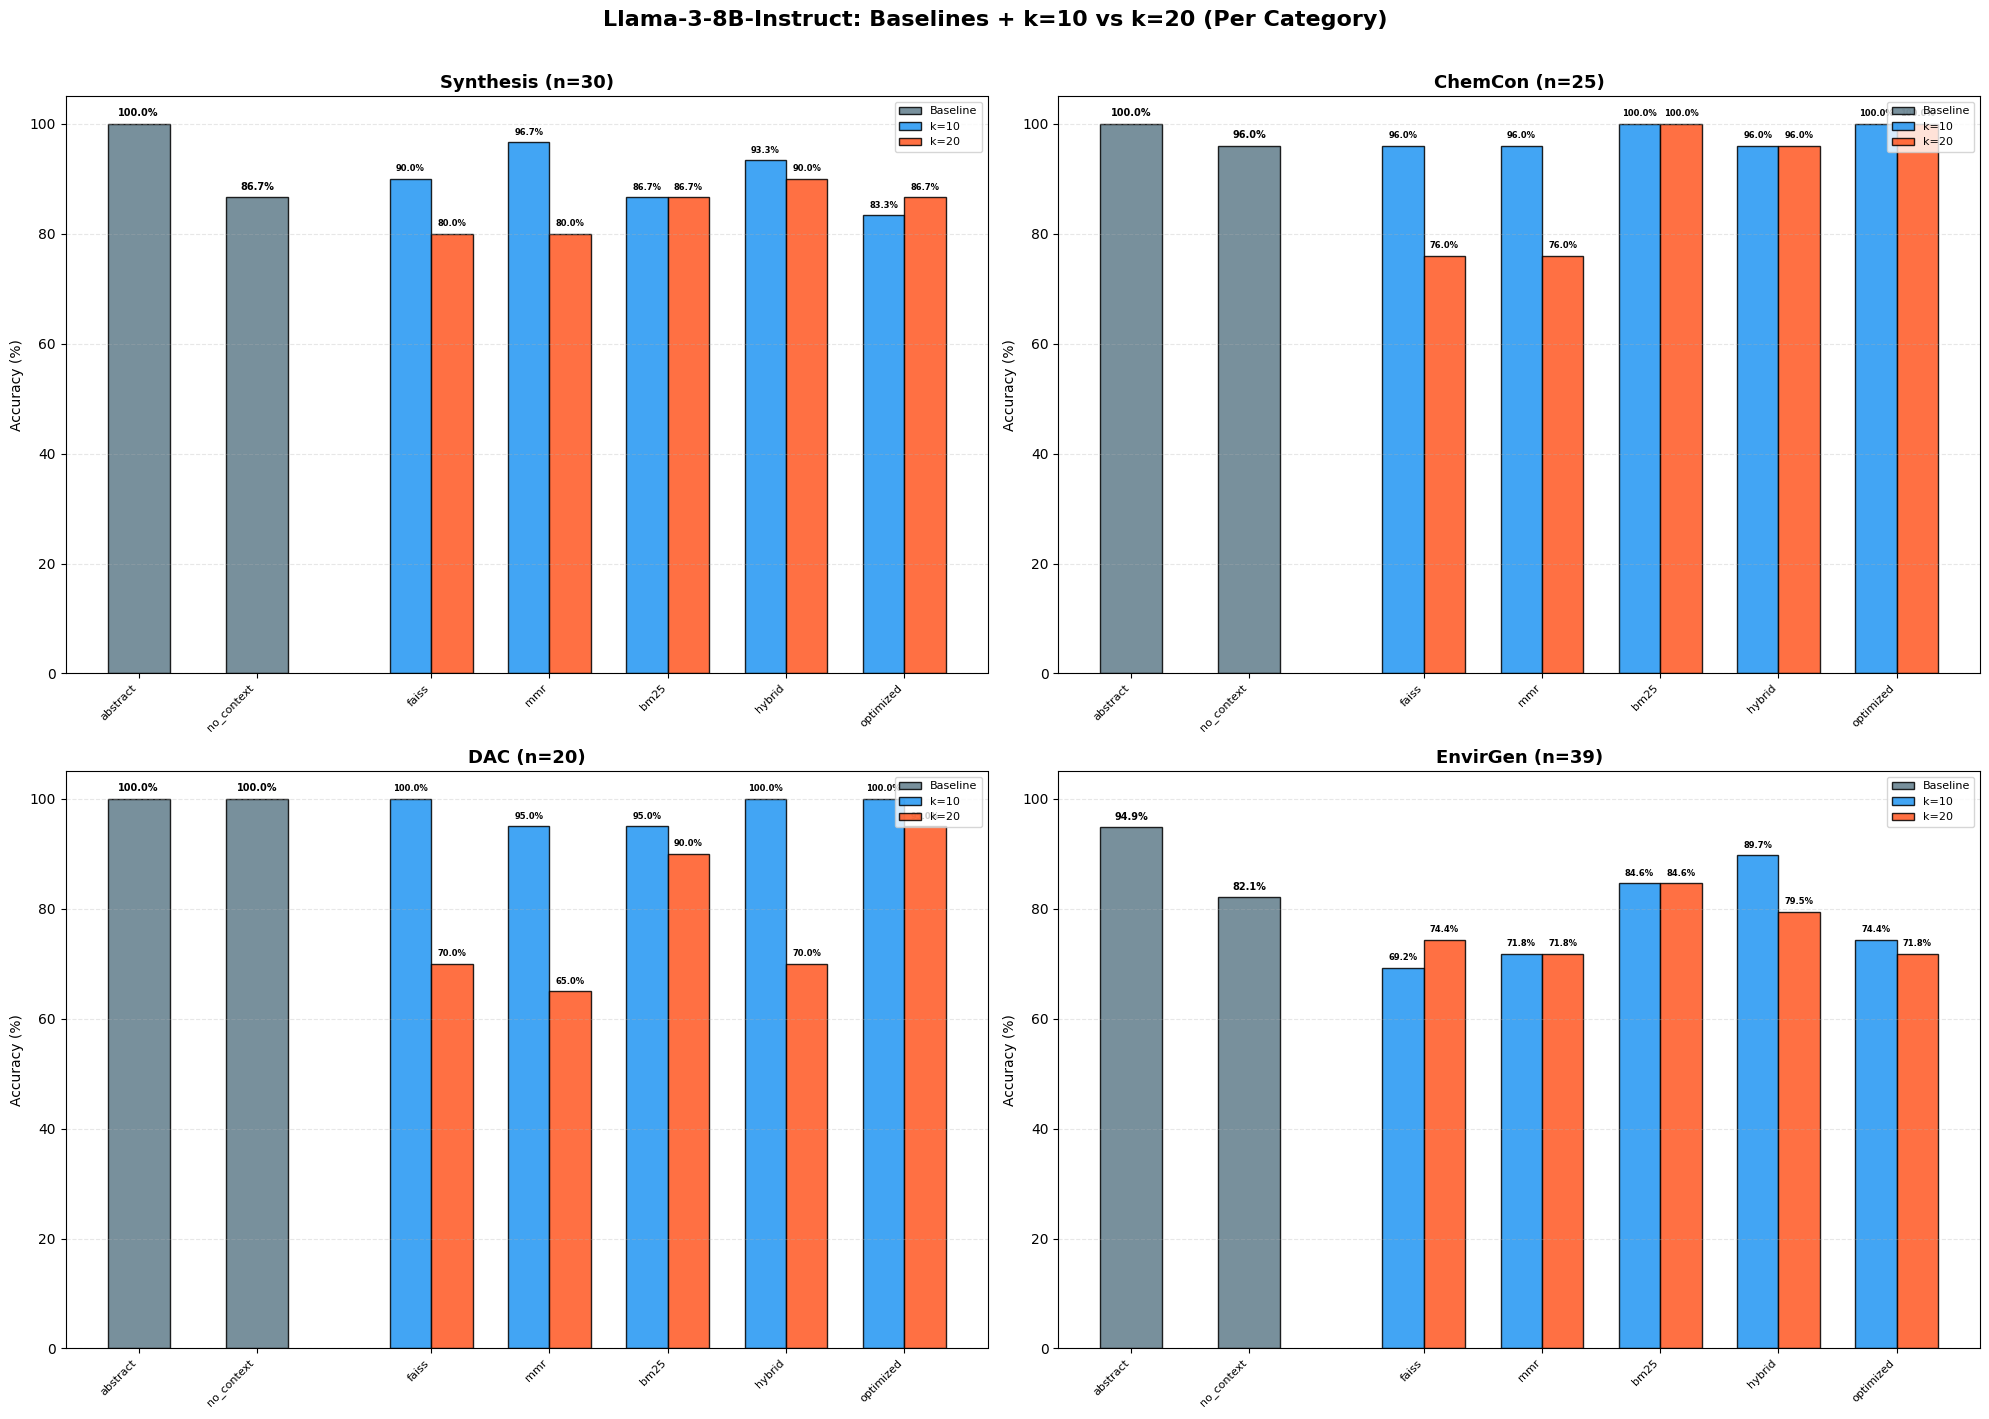

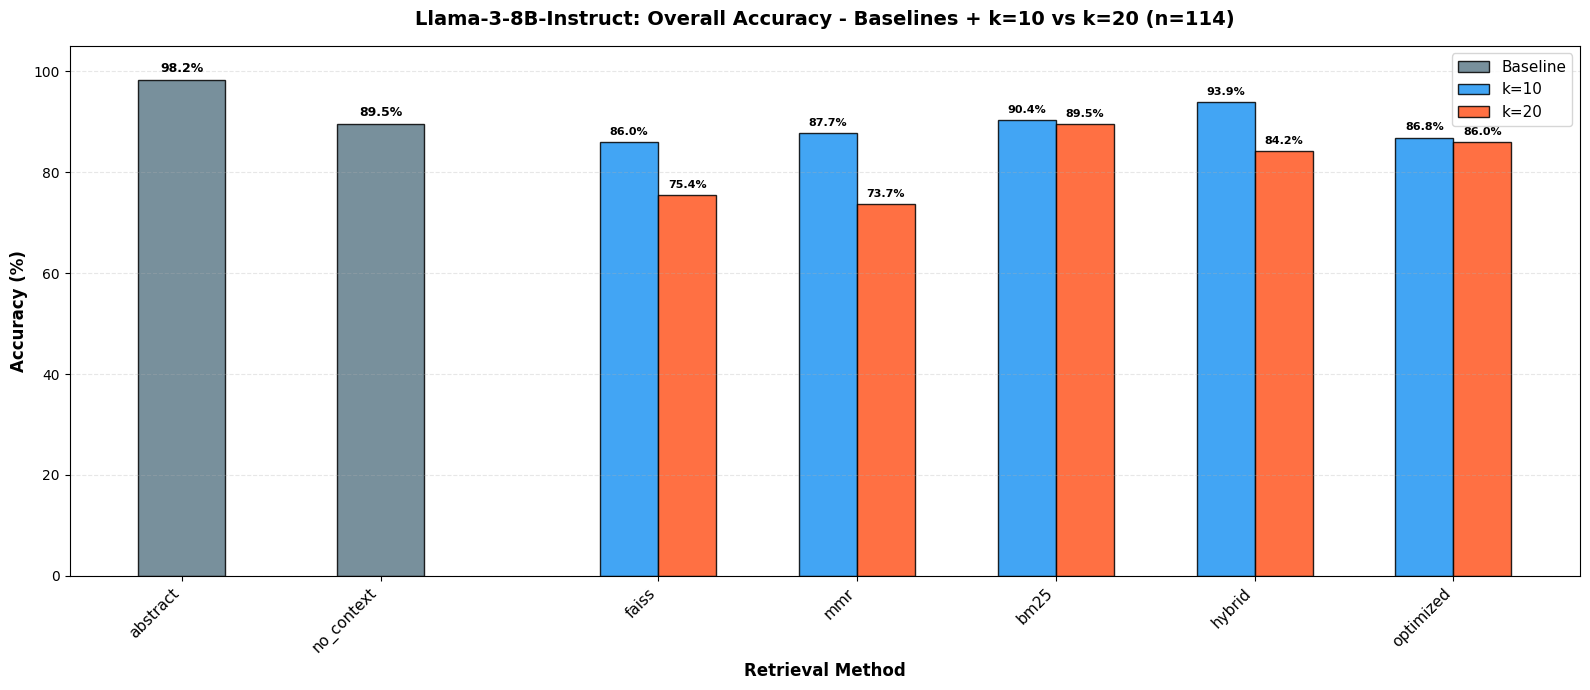

✓ Combined k=10 vs k=20 charts generated (per-category + overall)


In [18]:
import matplotlib.pyplot as plt
import numpy as np

baseline_methods = ['abstract', 'no_context']
retrieval_methods = ['faiss', 'mmr', 'bm25', 'hybrid', 'optimized']

# --- Print summary table per category ---
print("\n" + "="*110)
print("COMBINED RESULTS: Baselines + k=10 vs k=20 (Per Category + Overall)")
print("="*110)

for cat in ALL_CATEGORIES + ['Overall']:
    print(f"\n--- {cat} ---")
    print(f"{'Method':<15} {'Baseline':<12} {'k=10':<12} {'k=20':<12} {'k10→k20':<12}")
    print("-"*60)
    
    for m in baseline_methods:
        if cat == 'Overall':
            tc = sum(all_results[model_display_name]['k=10'][c][m]['correct_count'] for c in ALL_CATEGORIES)
            tn = sum(all_results[model_display_name]['k=10'][c][m]['total'] for c in ALL_CATEGORIES)
            acc = (tc / tn * 100) if tn > 0 else 0
        else:
            acc = all_results[model_display_name]['k=10'][cat][m]['accuracy']
        print(f"{m:<15} {acc:>6.2f}%      {'--':>6}       {'--':>6}       {'--':>6}")
    
    for m in retrieval_methods:
        if cat == 'Overall':
            tc10 = sum(all_results[model_display_name]['k=10'][c][m]['correct_count'] for c in ALL_CATEGORIES)
            tn10 = sum(all_results[model_display_name]['k=10'][c][m]['total'] for c in ALL_CATEGORIES)
            tc20 = sum(all_results[model_display_name]['k=20'][c][m]['correct_count'] for c in ALL_CATEGORIES)
            tn20 = sum(all_results[model_display_name]['k=20'][c][m]['total'] for c in ALL_CATEGORIES)
            acc10 = (tc10 / tn10 * 100) if tn10 > 0 else 0
            acc20 = (tc20 / tn20 * 100) if tn20 > 0 else 0
        else:
            acc10 = all_results[model_display_name]['k=10'][cat][m]['accuracy']
            acc20 = all_results[model_display_name]['k=20'][cat][m]['accuracy']
        delta = acc20 - acc10
        sign = '+' if delta >= 0 else ''
        print(f"{m:<15} {'--':>6}       {acc10:>6.2f}%      {acc20:>6.2f}%      {sign}{delta:.2f}%")

print("\n" + "="*110)

# --- Per-category grouped bar charts (4 panels) ---
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for idx, cat in enumerate(ALL_CATEGORIES):
    ax = axes[idx]
    
    bar_width = 0.35
    x_tick_positions = []
    x_tick_labels = []
    current_x = 0
    
    # Baselines (single bars)
    for i, m in enumerate(baseline_methods):
        acc = all_results[model_display_name]['k=10'][cat][m]['accuracy']
        ax.bar(current_x, acc, bar_width * 1.5, color='#607D8B', alpha=0.85, 
               edgecolor='black', label='Baseline' if i == 0 else None)
        ax.text(current_x, acc + 1, f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=7)
        x_tick_positions.append(current_x)
        x_tick_labels.append(m)
        current_x += 1.0
    
    current_x += 0.3
    
    # Retrieval methods (paired bars)
    for i, m in enumerate(retrieval_methods):
        x1 = current_x
        x2 = current_x + bar_width
        
        acc10 = all_results[model_display_name]['k=10'][cat][m]['accuracy']
        acc20 = all_results[model_display_name]['k=20'][cat][m]['accuracy']
        
        ax.bar(x1, acc10, bar_width, color='#2196F3', alpha=0.85, edgecolor='black',
               label='k=10' if i == 0 else None)
        ax.bar(x2, acc20, bar_width, color='#FF5722', alpha=0.85, edgecolor='black',
               label='k=20' if i == 0 else None)
        
        ax.text(x1, acc10 + 1, f'{acc10:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=6)
        ax.text(x2, acc20 + 1, f'{acc20:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=6)
        
        x_tick_positions.append((x1 + x2) / 2)
        x_tick_labels.append(m)
        current_x += 1.0
    
    n_q = len(category_dfs[cat])
    ax.set_title(f'{cat} (n={n_q})', fontsize=13, fontweight='bold')
    ax.set_xticks(x_tick_positions)
    ax.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Accuracy (%)')
    ax.legend(loc='upper right', fontsize=8, frameon=True)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, 105)

fig.suptitle(f'{model_display_name}: Baselines + k=10 vs k=20 (Per Category)', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Overall bar chart ---
fig2, ax2 = plt.subplots(figsize=(16, 7))

bar_width = 0.35
x_tick_positions = []
x_tick_labels = []
current_x = 0

for i, m in enumerate(baseline_methods):
    tc = sum(all_results[model_display_name]['k=10'][c][m]['correct_count'] for c in ALL_CATEGORIES)
    tn = sum(all_results[model_display_name]['k=10'][c][m]['total'] for c in ALL_CATEGORIES)
    acc = (tc / tn * 100) if tn > 0 else 0
    ax2.bar(current_x, acc, bar_width * 1.5, color='#607D8B', alpha=0.85, edgecolor='black',
            label='Baseline' if i == 0 else None)
    ax2.text(current_x, acc + 1, f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
    x_tick_positions.append(current_x)
    x_tick_labels.append(m)
    current_x += 1.2

current_x += 0.3

for i, m in enumerate(retrieval_methods):
    x1 = current_x
    x2 = current_x + bar_width
    
    tc10 = sum(all_results[model_display_name]['k=10'][c][m]['correct_count'] for c in ALL_CATEGORIES)
    tn10 = sum(all_results[model_display_name]['k=10'][c][m]['total'] for c in ALL_CATEGORIES)
    tc20 = sum(all_results[model_display_name]['k=20'][c][m]['correct_count'] for c in ALL_CATEGORIES)
    tn20 = sum(all_results[model_display_name]['k=20'][c][m]['total'] for c in ALL_CATEGORIES)
    acc10 = (tc10 / tn10 * 100) if tn10 > 0 else 0
    acc20 = (tc20 / tn20 * 100) if tn20 > 0 else 0
    
    ax2.bar(x1, acc10, bar_width, color='#2196F3', alpha=0.85, edgecolor='black',
            label='k=10' if i == 0 else None)
    ax2.bar(x2, acc20, bar_width, color='#FF5722', alpha=0.85, edgecolor='black',
            label='k=20' if i == 0 else None)
    
    ax2.text(x1, acc10 + 1, f'{acc10:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=8)
    ax2.text(x2, acc20 + 1, f'{acc20:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=8)
    
    x_tick_positions.append((x1 + x2) / 2)
    x_tick_labels.append(m)
    current_x += 1.2

ax2.set_xlabel('Retrieval Method', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title(f'{model_display_name}: Overall Accuracy - Baselines + k=10 vs k=20 (n=114)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x_tick_positions)
ax2.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=11)
ax2.legend(loc='upper right', frameon=True, fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

print("✓ Combined k=10 vs k=20 charts generated (per-category + overall)")

In [19]:
# Export combined k=10 and k=20 results to CSV (per-category + overall)
combined_data = []

for cat in ALL_CATEGORIES:
    # Baselines (k-independent)
    for m in baseline_methods:
        r = all_results[model_display_name]['k=10'][cat][m]
        combined_data.append({
            'model': model_display_name, 'k': 'baseline', 'category': cat,
            'method': m, 'accuracy': r.get('accuracy', 0),
            'correct': r.get('correct_count', 0), 'total': r.get('total', 0)
        })
    # Retrieval methods at k=10 and k=20
    for k_val in [10, 20]:
        for m in retrieval_methods:
            r = all_results[model_display_name][f'k={k_val}'][cat][m]
            combined_data.append({
                'model': model_display_name, 'k': k_val, 'category': cat,
                'method': m, 'accuracy': r.get('accuracy', 0),
                'correct': r.get('correct_count', 0), 'total': r.get('total', 0)
            })

# Overall rows
for m in baseline_methods:
    tc = sum(all_results[model_display_name]['k=10'][c][m]['correct_count'] for c in ALL_CATEGORIES)
    tn = sum(all_results[model_display_name]['k=10'][c][m]['total'] for c in ALL_CATEGORIES)
    combined_data.append({
        'model': model_display_name, 'k': 'baseline', 'category': 'Overall',
        'method': m, 'accuracy': (tc / tn * 100) if tn > 0 else 0,
        'correct': tc, 'total': tn
    })

for k_val in [10, 20]:
    for m in retrieval_methods:
        tc = sum(all_results[model_display_name][f'k={k_val}'][c][m]['correct_count'] for c in ALL_CATEGORIES)
        tn = sum(all_results[model_display_name][f'k={k_val}'][c][m]['total'] for c in ALL_CATEGORIES)
        combined_data.append({
            'model': model_display_name, 'k': k_val, 'category': 'Overall',
            'method': m, 'accuracy': (tc / tn * 100) if tn > 0 else 0,
            'correct': tc, 'total': tn
        })

combined_df = pd.DataFrame(combined_data)
combined_csv = f'results_greenonly_k10_k20_combined_{timestamp}.csv'
combined_df.to_csv(combined_csv, index=False)
print(f"Combined results exported to CSV: {combined_csv}")
print(f"\nTotal rows: {len(combined_df)}")
print(combined_df.to_string(index=False))

Combined results exported to CSV: results_greenonly_k10_k20_combined_20260224_181133.csv

Total rows: 60
              model        k  category     method   accuracy  correct  total
Llama-3-8B-Instruct baseline Synthesis   abstract 100.000000       30     30
Llama-3-8B-Instruct baseline Synthesis no_context  86.666667       26     30
Llama-3-8B-Instruct       10 Synthesis      faiss  90.000000       27     30
Llama-3-8B-Instruct       10 Synthesis        mmr  96.666667       29     30
Llama-3-8B-Instruct       10 Synthesis       bm25  86.666667       26     30
Llama-3-8B-Instruct       10 Synthesis     hybrid  93.333333       28     30
Llama-3-8B-Instruct       10 Synthesis  optimized  83.333333       25     30
Llama-3-8B-Instruct       20 Synthesis      faiss  80.000000       24     30
Llama-3-8B-Instruct       20 Synthesis        mmr  80.000000       24     30
Llama-3-8B-Instruct       20 Synthesis       bm25  86.666667       26     30
Llama-3-8B-Instruct       20 Synthesis     hybri

In [20]:
# Error analysis: k=10 correct → k=20 wrong (per category)
retrieval_methods_to_check = ['faiss', 'mmr', 'bm25', 'hybrid', 'optimized']

print("="*110)
print("ERROR ANALYSIS: Questions where k=10 was CORRECT but k=20 was WRONG (per category)")
print("="*110)

total_regressions = 0

for cat in ALL_CATEGORIES:
    print(f"\n{'#'*110}")
    print(f"CATEGORY: {cat} ({len(category_dfs[cat])} questions)")
    print(f"{'#'*110}")
    
    for method in retrieval_methods_to_check:
        k10_detailed = all_results[model_display_name]['k=10'][cat][method].get('detailed_results', [])
        k20_detailed = all_results[model_display_name]['k=20'][cat][method].get('detailed_results', [])
        
        if not k10_detailed or not k20_detailed:
            print(f"\n{method.upper()}: No detailed results available")
            continue
        
        regressions = []
        for i, (r10, r20) in enumerate(zip(k10_detailed, k20_detailed)):
            if r10.get('is_correct', False) and not r20.get('is_correct', False):
                regressions.append((i, r10, r20))
        
        if not regressions:
            print(f"\n{method.upper()}: No regressions")
            continue
        
        total_regressions += len(regressions)
        print(f"\n{method.upper()}: {len(regressions)} regression(s)")
        
        for idx, r10, r20 in regressions:
            print(f"  Q#{idx+1}: Correct={r10.get('correct_answer','?')} | "
                  f"k10={r10.get('model_answer','?')} ✓ | k20={r20.get('model_answer','?')} ✗")

print(f"\n{'='*110}")
print(f"TOTAL REGRESSIONS: {total_regressions}")
print(f"{'='*110}")

# Compact summary table
print(f"\n{'Category':<15} {'Method':<15} {'k=10 Acc':<12} {'k=20 Acc':<12} {'Regr.':<10} {'Impr.':<10}")
print("-"*75)
for cat in ALL_CATEGORIES:
    for method in retrieval_methods_to_check:
        k10_d = all_results[model_display_name]['k=10'][cat][method].get('detailed_results', [])
        k20_d = all_results[model_display_name]['k=20'][cat][method].get('detailed_results', [])
        
        regressions = sum(1 for r10, r20 in zip(k10_d, k20_d) 
                          if r10.get('is_correct') and not r20.get('is_correct'))
        improvements = sum(1 for r10, r20 in zip(k10_d, k20_d) 
                           if not r10.get('is_correct') and r20.get('is_correct'))
        
        k10_acc = all_results[model_display_name]['k=10'][cat][method]['accuracy']
        k20_acc = all_results[model_display_name]['k=20'][cat][method]['accuracy']
        
        print(f"{cat:<15} {method:<15} {k10_acc:>6.2f}%      {k20_acc:>6.2f}%      {regressions:<10} {improvements:<10}")
    print("-"*75)

ERROR ANALYSIS: Questions where k=10 was CORRECT but k=20 was WRONG (per category)

##############################################################################################################
CATEGORY: Synthesis (30 questions)
##############################################################################################################

FAISS: 4 regression(s)
  Q#10: Correct=B | k10=B ✓ | k20=INVALID ✗
  Q#13: Correct=B | k10=B ✓ | k20=INVALID ✗
  Q#21: Correct=B | k10=B ✓ | k20=INVALID ✗
  Q#24: Correct=C | k10=C ✓ | k20=INVALID ✗

MMR: 5 regression(s)
  Q#10: Correct=B | k10=B ✓ | k20=INVALID ✗
  Q#13: Correct=B | k10=B ✓ | k20=INVALID ✗
  Q#21: Correct=B | k10=B ✓ | k20=INVALID ✗
  Q#22: Correct=B | k10=B ✓ | k20=INVALID ✗
  Q#24: Correct=C | k10=C ✓ | k20=INVALID ✗

BM25: No regressions

HYBRID: 2 regression(s)
  Q#2: Correct=C | k10=C ✓ | k20=INVALID ✗
  Q#21: Correct=B | k10=B ✓ | k20=INVALID ✗

OPTIMIZED: No regressions

#######################################################